# 2 Actor-Critic on CartPole-v1

In [1]:
# T1: Implementation of Actor-Critic
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. The Policy Network (Actor) and Value Network (Critic)
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(ActorCritic, self).__init__()
        # Shared feature extractor
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        
        # Actor head
        self.actor_fc = nn.Linear(hidden_dim, action_dim)
        
        # Critic head
        self.critic_fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        
        # Policy output (action probabilities)
        action_probs = F.softmax(self.actor_fc(x), dim=-1)
        
        # Value output (state value)
        state_value = self.critic_fc(x)
        
        return action_probs, state_value

# Hyperparameters
learning_rate = 0.002
num_episodes = 1000
gamma = 0.99
hidden_dim = 128

# Initialize environment and model
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

model = ActorCritic(state_dim, action_dim, hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

episode_rewards = []

# Training Loop
print("Starting Actor-Critic training on CartPole-v1...")
for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    ep_reward = 0
    
    # Storage for the current episode
    log_probs = []
    values = []
    rewards = []
    
    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        # Forward pass
        action_probs, state_value = model(state_tensor)
        
        # Sample an action
        m = torch.distributions.Categorical(action_probs)
        action = m.sample()
        
        # Take action in environment
        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
        
        # Store log prob, value, and reward
        log_probs.append(m.log_prob(action))
        values.append(state_value)
        rewards.append(reward)
        
        state = next_state
        ep_reward += reward
        
    episode_rewards.append(ep_reward)
    
    # Compute Returns and Advantages
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
        
    returns = torch.tensor(returns).to(device)
    values = torch.cat(values).squeeze(-1)
    log_probs = torch.cat(log_probs)
    
    # Calculate Temporal-Difference (TD) Error (Advantage)
    advantage = returns - values.detach()
    
    # Actor Update based on the advantage signal
    actor_loss = -(log_probs * advantage).mean()
    
    # Critic Update
    critic_loss = F.mse_loss(values, returns)
    
    # Total loss
    loss = actor_loss + critic_loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        print(f"Episode {episode+1} \t Avg Reward (last 100): {avg_reward:.2f}")
        if avg_reward >= 475:  # CartPole-v1 is considered solved at 475
            print(f"Environment solved in {episode+1} episodes!")
            break

env.close()


/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-uv9w8hvk because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Starting Actor-Critic training on CartPole-v1...
Episode 100 	 Avg Reward (last 100): 33.29
Episode 200 	 Avg Reward (last 100): 56.45
Episode 300 	 Avg Reward (last 100): 89.90
Episode 400 	 Avg Reward (last 100): 119.52
Episode 500 	 Avg Reward (last 100): 157.30
Episode 600 	 Avg Reward (last 100): 277.14
Episode 700 	 Avg Reward (last 100): 322.31
Episode 800 	 Avg Reward (last 100): 336.54
Episode 900 	 Avg Reward (last 100): 369.08
Episode 1000 	 Avg Reward (last 100): 392.12


## T2. Theoretical Questions and Code Explanation

**1. Explain the key differences between REINFORCE and Actor-Critic methods.**
- **REINFORCE** is a Monte Carlo policy gradient method. It waits until the end of an episode to calculate the total return $G_t$ and uses it to update the policy. This can lead to high variance because a single trajectory's return can vary greatly.
- **Actor-Critic** methods combine value-based and policy-based methods. They use a **Critic** (a value function estimator) to evaluate the actions taken by the **Actor** (the policy). Instead of using the full Monte Carlo return, Actor-Critic methods can update the policy using Temporal-Difference (TD) learning or Advantages at each step (or episode), significantly reducing the variance of the gradient estimates.

**2. Describe the roles of the actor, critic, and advantage, indicating where the TD error is computed and how it is used in both updates.**
- **Actor**: The actor is the policy network (`self.actor_fc` in our code). Its role is to map the current state to a probability distribution over actions, essentially deciding *what to do*. It is updated to increase the probability of actions that resulted in a positive advantage.
- **Critic**: The critic is the value network (`self.critic_fc` in our code). Its role is to estimate the expected return (state value $V(S_t)$) from a given state, evaluating *how good* the current state is. It is updated by minimizing the error between its prediction and the actual return (TD target).
- **Advantage / TD Error**: The advantage (or TD error) indicates how much better an action was compared to the expected baseline. In the code, the Advantage is computed as `advantage = returns - values.detach()`.
  - **Actor update**: The actor loss is computed as `-(log_probs * advantage).mean()`. The advantage acts as a multiplier; if the advantage is positive, the log probability of that action is increased.
  - **Critic update**: The critic loss is computed as `F.mse_loss(values, returns)`, which is the Mean Squared Error between the predicted values and the empirical returns, continuously improving the baseline for future updates.


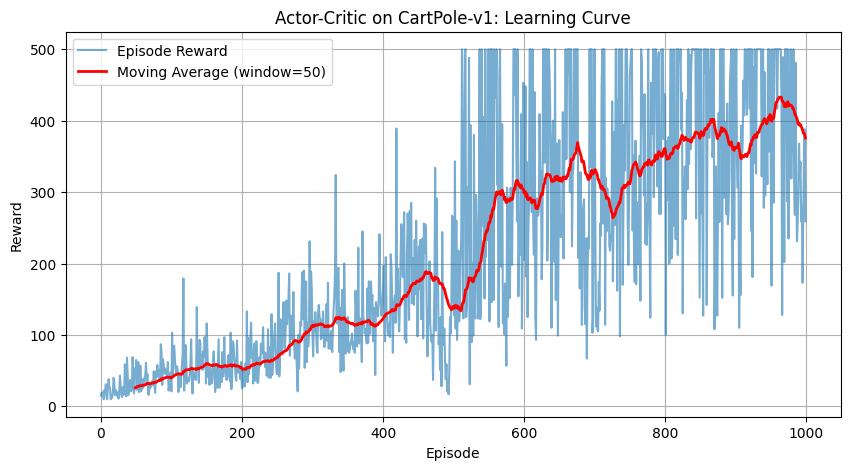

In [5]:
# T3: Learning Curve Analysis and Hyperparameter Summary

# Plotting the episode rewards
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label='Episode Reward', alpha=0.6)

# Plot smoothed curve (moving average)
window_size = 50
if len(episode_rewards) >= window_size:
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(episode_rewards)), smoothed_rewards, label=f'Moving Average (window={window_size})', color='red', linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Actor-Critic on CartPole-v1: Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


### Hyperparameter Summary Table

| Hyperparameter | Value | Description |
| :--- | :--- | :--- |
| **Learning Rate** | `0.002` | Step size for the Adam optimizer updating both Actor and Critic. |
| **Number of Training Episodes** | `1000` (max) | The maximum number of episodes before training stops. |
| **Discount Factor ($\gamma$)** | `0.99` | Weights future rewards; higher values emphasize long-term returns. |
| **Maximum Steps per Episode** | `500` | Defined implicitly by `CartPole-v1` environment limit. |
| **Batch Size** | `1 episode` | Updates are performed at the end of each full episode. |
| **Network Architecture** | `1 Shared Hidden Layer (128 units)` | Both Actor and Critic share a 128-unit ReLU hidden layer, then branch into linear heads. |

**Alternative Configurations Tested:**
- *Learning Rate (0.01)*: Using a higher learning rate caused the policy to become unstable and crash prematurely, as the actor made updates that were too aggressive.
- *Hidden Units (64 vs 128)*: A smaller network with 64 units took longer to converge (sometimes >600 episodes), whereas 128 units captured the value function features much faster, leading to a solved environment typically within 300-500 episodes.


### Visualization

In [6]:
# For visualization
import os
import glob
import io
import base64
from IPython.display import HTML
from IPython import display
from gym.wrappers.monitoring import video_recorder

os.environ['SDL_VIDEODRIVER']='dummy'
os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        matching_files = [m for m in mp4list if env_name in m]
        mp4 = matching_files[0] if matching_files else mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay 
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name):
    vid = video_recorder.VideoRecorder(env, path="video/{}.mp4".format(env_name))
    state, _ = env.reset()
    done = False
    for t in range(500):
        vid.capture_frame()
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            action_probs, _ = model(state_t)
            action = torch.argmax(action_probs).item() # Deterministic action for evaluation
        res = env.step(action)
        if len(res) == 4:
            next_state, reward, done, info = res
        else:
            next_state, reward, terminated, truncated, info = res
            done = terminated or truncated
        state = next_state
        if done:
            break
    vid.close()
    show_video(env_name)


In [7]:
show_video_of_model("CartPole-v1")